# 05 - Empirical horserace evaluation

Comparison tables, pairwise Diebold–Mariano tests, and diagnostic plots built from the outputs of notebooks 02–04.


In [6]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'empirical' / 'results').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from minou_colors import MINOU_COLORS
RESULTS_DIR = ROOT / 'empirical' / 'results'
FIGURES_DIR = ROOT / 'empirical' / 'figures' / '05_horserace'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SPLITS = ('modern', 'stress')
FAMILIES = {'PTO':'pto', 'Black-box':'blackbox', 'DFL':'dfl'}
MODEL_ORDER = ['pto_mlp','blackbox_mlp','dfl_mlp','pto_linear','blackbox_linear','dfl_linear','persistence']
COLORS = {'pto_mlp':MINOU_COLORS['teal'], 'blackbox_mlp':MINOU_COLORS['navy'], 'dfl_mlp':MINOU_COLORS['sage'], 'pto_linear':MINOU_COLORS['gold'], 'blackbox_linear':MINOU_COLORS['coral'], 'dfl_linear':MINOU_COLORS['purple'], 'persistence':MINOU_COLORS['grey']}


In [7]:
def load_split(split):
    frames = {}
    for label, family in FAMILIES.items():
        p = RESULTS_DIR / family / f'{family}_quarterly_pd_irb_predictions_{split}.csv'
        frame = pd.read_csv(p, parse_dates=['date'])
        if family == 'pto':
            frame = frame.rename(columns={c: c.replace('_mlp', '_pto_mlp').replace('_linear', '_pto_linear').replace('_persistence', '_pto_persistence') for c in frame.columns if c.startswith(('alpha_hat_', 'regret_', 'utility_', 'pd_q_hat_', 'pd_a_hat_', 'c_q_hat_', 'k_irb_hat_'))})
        frames[family] = frame
    # Merge on date; keep one realised/oracle copy and all model-specific columns.
    merged = frames['pto'].copy()
    for family in ('blackbox','dfl'):
        extra = frames[family].drop(columns=[c for c in merged.columns if c in frames[family].columns and c not in ['date']], errors='ignore')
        merged = merged.merge(extra, on='date', how='inner')
    return merged.sort_values('date').reset_index(drop=True)

data = {s: load_split(s) for s in SPLITS}
for s, df in data.items(): print(s, df.shape, df['date'].min(), df['date'].max())


modern (36, 58) 2017-04-01 00:00:00 2026-01-01 00:00:00
stress (81, 58) 2006-01-01 00:00:00 2026-01-01 00:00:00


In [8]:
def available_models(df):
    return [m for m in MODEL_ORDER if f'regret_{m}' in df and f'alpha_hat_{m}' in df]

def summary_table(df):
    models = available_models(df)
    regret = df[[f'regret_{m}' for m in models]].to_numpy(float)
    winners = np.isclose(regret, regret.min(axis=1, keepdims=True), atol=1e-12)
    rows = []
    for j, m in enumerate(models):
        rows.append({'model':m, 'n':len(df), 'mean_regret':np.nanmean(regret[:,j]), 'median_regret':np.nanmedian(regret[:,j]), 'mean_alpha':df[f'alpha_hat_{m}'].mean(), 'win_share':np.nanmean(winners[:,j] / winners.sum(axis=1))})
    return pd.DataFrame(rows).sort_values('mean_regret')

summaries = {s: summary_table(df) for s, df in data.items()}
for s, table in summaries.items():
    print('\n', s); display(table)
    table.to_csv(FIGURES_DIR / f'{s}_summary.csv', index=False)



 modern


,model,n,mean_regret,median_regret,mean_alpha,win_share
0,blackbox_mlp,36,0.010670,0.007155,0.599722,0.097222
3,dfl_linear,36,0.012325,0.011121,0.587500,0.078704
1,dfl_mlp,36,0.052979,0.007875,0.595278,0.050926
4,persistence,36,0.101174,0.006535,0.665833,0.379630
2,blackbox_linear,36,0.195929,0.006270,0.647500,0.393519



 stress


,model,n,mean_regret,median_regret,mean_alpha,win_share
0,blackbox_mlp,81,0.011070,0.007850,0.574815,0.123457
1,dfl_mlp,81,0.040711,0.009405,0.571235,0.139918
3,dfl_linear,81,0.044738,0.012840,0.546914,0.065844
4,persistence,81,0.110487,0.006430,0.639012,0.415638
2,blackbox_linear,81,0.136926,0.009705,0.596667,0.255144


In [9]:
def nw_lrv(x, lags):
    x = np.asarray(x, float); x = x - np.nanmean(x); n = len(x)
    out = np.nanmean(x*x)
    for k in range(1, min(lags, n-1)+1): out += 2*(1-k/(lags+1))*np.nanmean(x[k:]*x[:-k])
    return out

def dm_test(a, b):
    d = np.asarray(a, float) - np.asarray(b, float); d = d[np.isfinite(d)]; n = len(d)
    if n < 4 or np.isclose(d.var(), 0): return np.nan, np.nan
    lags = max(1, int(np.floor(4*(n/100)**(2/9))))
    stat = d.mean() / np.sqrt(nw_lrv(d, lags)/n)
    # Harvey small-sample correction, matching the source notebooks.
    stat *= np.sqrt((n + 1 - 2*lags + lags*(lags-1)/n) / n)
    return stat, 2*stats.t.sf(abs(stat), n-1)

def pairwise_dm(df):
    models = available_models(df); rows=[]
    for row in models:
        for col in models:
            if row == col: continue
            stat, p = dm_test(df[f'regret_{row}'], df[f'regret_{col}'])
            rows.append({'row_model':row, 'column_model':col, 'dm_stat':stat, 'p_value':p})
    return pd.DataFrame(rows)

dm_tables = {s: pairwise_dm(df) for s, df in data.items()}
for s, table in dm_tables.items(): table.to_csv(FIGURES_DIR / f'{s}_pairwise_dm_regret.csv', index=False); print(s); display(table)


modern


,row_model,column_model,dm_stat,p_value
0,blackbox_mlp,dfl_mlp,-1.022306,0.313650
1,blackbox_mlp,blackbox_linear,-1.452273,0.155332
2,blackbox_mlp,dfl_linear,-1.295059,0.203778
3,blackbox_mlp,persistence,-2.372453,0.023297
4,dfl_mlp,blackbox_mlp,1.022306,0.313650
5,dfl_mlp,blackbox_linear,-1.576072,0.124006
6,dfl_mlp,dfl_linear,0.974724,0.336386
7,dfl_mlp,persistence,-0.779151,0.441128
8,blackbox_linear,blackbox_mlp,1.452273,0.155332
9,blackbox_linear,dfl_mlp,1.576072,0.124006


stress


,row_model,column_model,dm_stat,p_value
0,blackbox_mlp,dfl_mlp,-1.450194,0.150914
1,blackbox_mlp,blackbox_linear,-2.041872,0.044460
2,blackbox_mlp,dfl_linear,-2.151658,0.034440
3,blackbox_mlp,persistence,-3.694312,0.000402
4,dfl_mlp,blackbox_mlp,1.450194,0.150914
5,dfl_mlp,blackbox_linear,-1.939028,0.056024
6,dfl_mlp,dfl_linear,-0.176910,0.860026
7,dfl_mlp,persistence,-2.014698,0.047296
8,blackbox_linear,blackbox_mlp,2.041872,0.044460
9,blackbox_linear,dfl_mlp,1.939028,0.056024


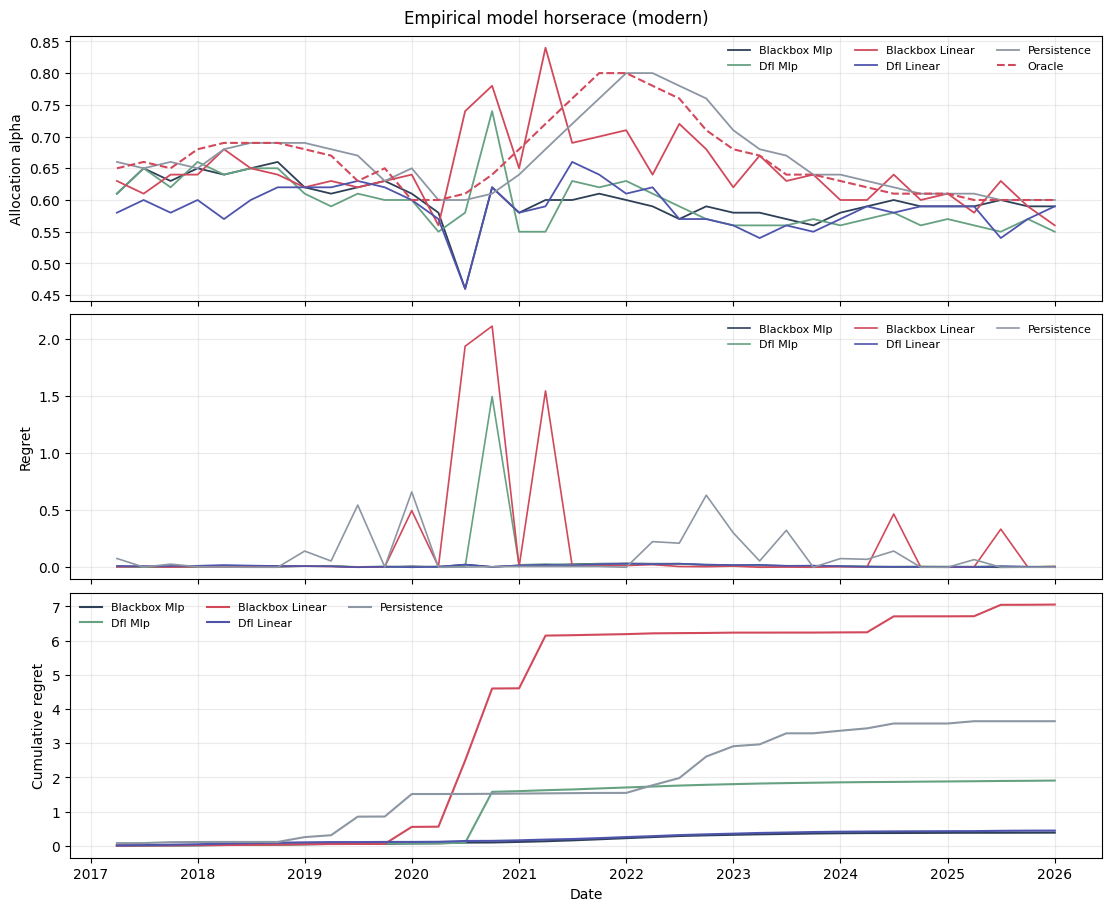

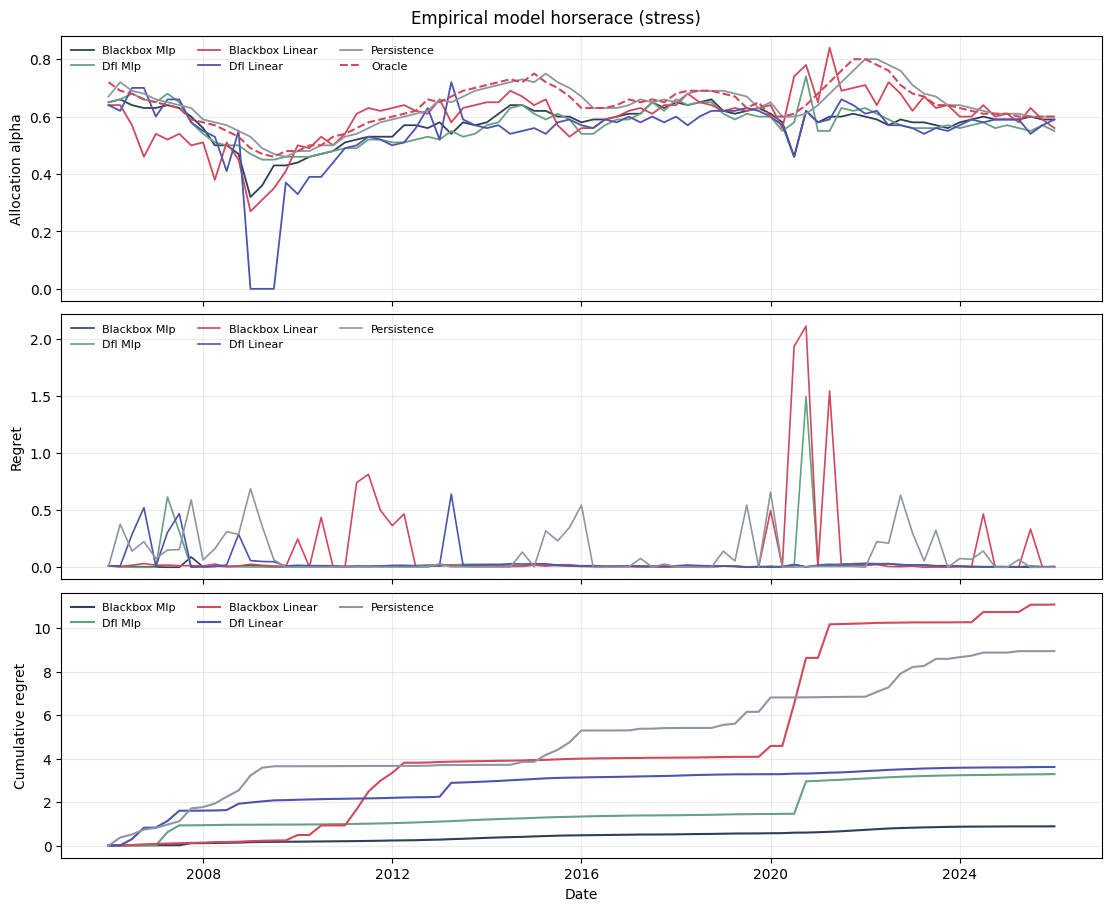

In [10]:
for split, df in data.items():
    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
    for m in available_models(df):
        label = m.replace('_',' ').title()
        axes[0].plot(df['date'], df[f'alpha_hat_{m}'], lw=1.3, color=COLORS[m], label=label)
        axes[1].plot(df['date'], df[f'regret_{m}'], lw=1.2, color=COLORS[m], label=label)
        axes[2].plot(df['date'], df[f'regret_{m}'].cumsum(), lw=1.5, color=COLORS[m], label=label)
    axes[0].plot(df['date'], df['alpha_oracle'], '--', color=MINOU_COLORS['coral'], label='Oracle')
    axes[0].set_ylabel('Allocation alpha'); axes[1].set_ylabel('Regret'); axes[2].set_ylabel('Cumulative regret'); axes[2].set_xlabel('Date')
    for ax in axes: ax.grid(alpha=.25); ax.legend(frameon=False, fontsize=8, ncol=3)
    fig.suptitle(f'Empirical model horserace ({split})')
    fig.savefig(FIGURES_DIR / f'{split}_horserace.png', dpi=220, bbox_inches='tight'); plt.show()
